
Clone the GitHub repository 'https://github.com/johnkennedyls/Investigative-Project-On-Steroids'.

## Install Git




**Reasoning**:
To check if Git is already installed, I will execute the `!git --version` command in a code cell.



In [ ]:
!git --version

git version 2.34.1


## Authenticate with GitHub




In [ ]:
github_token = 'REMOVED' # Replace 'YOUR_PAT_HERE' with your actual GitHub Personal Access Token

 the next step is to construct the full clone URL using the PAT and the repository information, and then execute the `git clone` command to download the repository.



In [ ]:
repository_url = 'github.com/johnkennedyls/Investigative-Project-On-Steroids.git'
clone_url = f'https://{github_token}@{repository_url}'

# Execute the git clone command
!git clone {clone_url}
print(f"Repository '{repository_url}' cloned successfully.")

fatal: destination path 'Investigative-Project-On-Steroids' already exists and is not an empty directory.
Repository 'github.com/johnkennedyls/Investigative-Project-On-Steroids.git' cloned successfully.



Confirm that the repository has been cloned


### Confirmar la clonación del repositorio

Para verificar que el repositorio `Investigative-Project-On-Steroids` se ha clonado correctamente, listaremos el contenido del directorio actual. Deberías ver una carpeta con el nombre del repositorio.

In [ ]:
# Listar los contenidos del directorio actual
!ls -F

# Opcional: para ver los contenidos específicos del repositorio clonado, puedes ejecutar:
# !ls -F Investigative-Project-On-Steroids/

Investigative-Project-On-Steroids/  mst_mr_final.pth  sample_data/


### Listar todas las carpetas y subcarpetas del repositorio

Para obtener una vista completa de la estructura de directorios del repositorio clonado, usaremos el comando `!ls -R` dentro de la carpeta del repositorio. Esto listará recursivamente todos los archivos y directorios.

In [ ]:
# Listar recursivamente los contenidos del repositorio clonado
!ls -R Investigative-Project-On-Steroids/

Investigative-Project-On-Steroids/:
'~$L y tratamiento inicial de datos.docx'   recommender_data_final_uni
 docs					    tabla_maestra
 lirycs1950-2019			    talkplay_datasets_divididos
 master_dataset_73k			    wasabi_full_parquet_nofilters
 README.md

Investigative-Project-On-Steroids/docs:
'Anteproyecto FEP - John Kennedy Landazuri Sandoval_CCOQ.docx'
'Anteproyecto FEP - John Kennedy Landazuri Sandoval.docx'
'CRONOGRAMA COMPLETO_.xlsx'
'EchoPulseAI architecture.md'
'EchoPulse AI visual Architecture diagram.svg'
'Estado del arte transformers.pdf'
'ETL y tratamiento inicial de datos.docx'
'tabla de presupuesto.xlsx'
 Tabla_Maestra.ipynb

Investigative-Project-On-Steroids/lirycs1950-2019:
test  train  valid

Investigative-Project-On-Steroids/lirycs1950-2019/test:
part-00000-0d92d707-47db-4a3e-a47b-db30cac648a9-c000.snappy.parquet  _SUCCESS

Investigative-Project-On-Steroids/lirycs1950-2019/train:
part-00000-8026d572-5daf-49f4-b065-649a524fe36c-c000.snappy.parquet  _SUCCESS

Investigati

📊 Análisis del Dataset (Entrada del Transformer)

Clase transformer

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import re
import time
from collections import Counter

# --- 1. CARGA DE DATOS ---
PATH_TRAIN = "Investigative-Project-On-Steroids/tabla_maestra/train/part-00000-0cbbc0cd-4603-4851-afb0-2f9a0fa6eb89-c000.snappy.parquet"
print("📂 Cargando Parquet...")
df_train = pd.read_parquet(PATH_TRAIN)

# Identificar las 26 columnas técnicas
tech_features = df_train.select_dtypes(include=['number']).columns.tolist()
tech_features = [c for c in tech_features if 'id' not in c.lower()][:26]

# --- 2. TOKENIZER PROPIETARIO ---
class EchoPulseTokenizer:
    def __init__(self, max_len=151):
        self.vocab = {"<PAD>": 0, "<UNK>": 1}
        self.max_len = max_len

    def fit(self, lyrics_list):
        words = []
        for text in lyrics_list:
            clean_text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
            words.extend(clean_text.split())
        counts = Counter(words)
        for word, count in counts.items():
            if count >= 2: self.vocab[word] = len(self.vocab)
        print(f"✨ Vocabulario: {len(self.vocab)} palabras.")

    def encode(self, text):
        clean_text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower()).split()
        encoded = [self.vocab.get(w, 1) for w in clean_text][:self.max_len]
        return encoded + [0] * (self.max_len - len(encoded))

tokenizer = EchoPulseTokenizer(max_len=151)
tokenizer.fit(df_train['lyrics'].tolist())

# --- 3. DEFINICIÓN DEL MODELO MST-MR ---
class MST_MR_Transformer(nn.Module):
    def __init__(self, vocab_size, n_tech=26, d_model=512, nhead=8, num_layers=6, max_len=151):
        super().__init__()
        self.lyric_emb = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Parameter(torch.zeros(1, max_len, d_model))
        self.tech_projection = nn.Sequential(nn.Linear(n_tech, 256), nn.GELU(), nn.Linear(256, d_model))
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        self.norm_fusion = nn.LayerNorm(d_model)
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, d_model)

    def forward(self, lyrics_idx, tech_features):
        x_lyric = self.lyric_emb(lyrics_idx) + self.pos_encoding[:, :lyrics_idx.size(1), :]
        x_tech = self.tech_projection(tech_features).unsqueeze(1)
        attn_out, _ = self.cross_attn(x_lyric, x_tech, x_tech)
        memory = self.norm_fusion(attn_out + x_lyric)
        dec_out = self.decoder(x_lyric, memory)
        return self.fc_out(torch.mean(dec_out, dim=1))

# --- 4. DATASET Y ESCALADO ---
print("🧹 Limpiando y escalando datos...")
df_train[tech_features] = df_train[tech_features].fillna(0)
scaler = MinMaxScaler()
df_train[tech_features] = scaler.fit_transform(df_train[tech_features])

class MST_MR_Dataset(Dataset):
    def __init__(self, df, tokenizer, tech_cols):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.tech_cols = tech_cols
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        lyrics = torch.tensor(self.tokenizer.encode(row['lyrics']), dtype=torch.long)
        tech = torch.tensor(row[self.tech_cols].values.astype('float32'), dtype=torch.float)
        return lyrics, tech

train_loader = DataLoader(MST_MR_Dataset(df_train, tokenizer, tech_features), batch_size=32, shuffle=True)

# --- 5. ENTRENAMIENTO ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MST_MR_Transformer(vocab_size=len(tokenizer.vocab)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

print(f"🔥 Entrenando en {device}...")
for epoch in range(15):
    model.train()
    total_loss = 0
    for i, (lyrics, tech) in enumerate(train_loader):
        lyrics, tech = lyrics.to(device), tech.to(device)
        optimizer.zero_grad()
        output = model(lyrics, tech)
        loss = criterion(output[:, :26], tech)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if i % 50 == 0: print(f" Epoch {epoch+1} | Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

    print(f"✅ ÉPOCA {epoch+1} FINALIZADA. Loss promedio: {total_loss/len(train_loader):.4f}")

# Guardar el estado
torch.save({'model': model.state_dict(), 'vocab': tokenizer.vocab, 'scaler': scaler}, 'mst_mr_final.pth')
print("💾 Modelo guardado exitosamente.")

📂 Cargando Parquet...
✨ Vocabulario: 9880 palabras.
🧹 Limpiando y escalando datos...
🔥 Entrenando en cuda...
 Epoch 1 | Batch 0/179 | Loss: 0.4524
 Epoch 1 | Batch 50/179 | Loss: 0.0285
 Epoch 1 | Batch 100/179 | Loss: 0.0214
 Epoch 1 | Batch 150/179 | Loss: 0.0180
✅ ÉPOCA 1 FINALIZADA. Loss promedio: 0.0289
 Epoch 2 | Batch 0/179 | Loss: 0.0127
 Epoch 2 | Batch 50/179 | Loss: 0.0101
 Epoch 2 | Batch 100/179 | Loss: 0.0079
 Epoch 2 | Batch 150/179 | Loss: 0.0057
✅ ÉPOCA 2 FINALIZADA. Loss promedio: 0.0088
 Epoch 3 | Batch 0/179 | Loss: 0.0063
 Epoch 3 | Batch 50/179 | Loss: 0.0043
 Epoch 3 | Batch 100/179 | Loss: 0.0038
 Epoch 3 | Batch 150/179 | Loss: 0.0051
✅ ÉPOCA 3 FINALIZADA. Loss promedio: 0.0043
 Epoch 4 | Batch 0/179 | Loss: 0.0024
 Epoch 4 | Batch 50/179 | Loss: 0.0022
 Epoch 4 | Batch 100/179 | Loss: 0.0030
 Epoch 4 | Batch 150/179 | Loss: 0.0023
✅ ÉPOCA 4 FINALIZADA. Loss promedio: 0.0025
 Epoch 5 | Batch 0/179 | Loss: 0.0020
 Epoch 5 | Batch 50/179 | Loss: 0.0015
 Epoch 5 |

Analizar modelo

In [ ]:
import os
file_size = os.path.getsize('mst_mr_final.pth') / (1024 * 1024)
print(f"Tamaño del modelo: {file_size:.2f} MB")

Tamaño del modelo: 121.59 MB


Subida a github modelo

In [ ]:
# CONFIGURACIÓN
USER_NAME = "johnkennedyls"
USER_EMAIL = "jkls1998@gmail.com"
TOKEN = github_token  # El Personal Access Token (PAT)
REPO_NAME = "Investigative-Project-On-Steroids"

# Configurar Git
!git config --global user.email "{USER_EMAIL}"
!git config --global user.name "{USER_NAME}"

In [ ]:
# Volver a la raíz de Colab para encontrar el archivo
%cd /content/
# Moverlo a la carpeta del repo
!mv mst_mr_final.pth {REPO_NAME}/
# Entrar al repo
%cd {REPO_NAME}/

# Registrar en LFS correctamente
!git lfs track "*.pth"
!git add .gitattributes
!git add mst_mr_final.pth

/content
/content/Investigative-Project-On-Steroids
"*.pth" already supported


In [ ]:
!git commit -m "Add MST-MR Transformer model weights (121MB) with LFS"

# Construir URL con autenticación
remote_url = f"https://{TOKEN}@github.com/{USER_NAME}/{REPO_NAME}.git"

# Empujar los datos
!git push {remote_url} --all

[main a331df0] Add MST-MR Transformer model weights (121MB) with LFS
 76 files changed, 4 insertions(+), 2409 deletions(-)
 delete mode 100644 README.md
 delete mode 100644 docs/Anteproyecto FEP - John Kennedy Landazuri Sandoval.docx
 delete mode 100644 docs/Anteproyecto FEP - John Kennedy Landazuri Sandoval_CCOQ.docx
 delete mode 100644 docs/CRONOGRAMA COMPLETO_.xlsx
 delete mode 100644 docs/ETL y tratamiento inicial de datos.docx
 delete mode 100644 docs/EchoPulse AI visual Architecture diagram.svg
 delete mode 100644 docs/EchoPulseAI architecture.md
 delete mode 100644 docs/Estado del arte transformers.pdf
 delete mode 100644 docs/Tabla_Maestra.ipynb
 delete mode 100644 docs/tabla de presupuesto.xlsx
 delete mode 100644 lirycs1950-2019/test/._SUCCESS.crc
 delete mode 100644 lirycs1950-2019/test/.part-00000-0d92d707-47db-4a3e-a47b-db30cac648a9-c000.snappy.parquet.crc
 delete mode 100644 lirycs1950-2019/test/_SUCCESS
 delete mode 100644 lirycs1950-2019/test/part-00000-0d92d707-47db-4a

1. Carga del Set de Test y Generación de Embeddings

In [ ]:
import os
import glob
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics.pairwise import cosine_similarity

# 1. Localización del archivo de Test
REPO_PATH = "/content/Investigative-Project-On-Steroids"
TEST_PATTERN = os.path.join(REPO_PATH, "tabla_maestra/test/*.parquet")
test_files = glob.glob(TEST_PATTERN)

if not test_files:
    print("❌ No se encontró el archivo de test. Revisa la ruta.")
else:
    # Carga del DataFrame de Test
    df_test = pd.read_parquet(test_files[0])

    # Aplicar el mismo escalado que en el entrenamiento
    df_test[tech_features] = scaler.transform(df_test[tech_features].fillna(0))

    # 2. Generación de Embeddings para el Test
    test_ds = MST_MR_Dataset(df_test, tokenizer, tech_features)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

    model.eval()
    all_embeddings = []

    print(f"🧠 Indexando {len(df_test)} canciones del set de test...")
    with torch.no_grad():
        for lyrics, tech in test_loader:
            lyrics, tech = lyrics.to(device), tech.to(device)
            # Obtenemos el vector de 512D del Transformer
            embeddings = model(lyrics, tech)
            all_embeddings.append(embeddings.cpu().numpy())

    # Matriz final de búsqueda
    test_embeddings = np.vstack(all_embeddings)
    print("✅ Indexación completada.")

    # 3. Función de Búsqueda Top 10
    def obtener_top_10(query_idx, embeddings_db, df_metadata):
        # Vector de la canción elegida
        query_vec = embeddings_db[query_idx].reshape(1, -1)

        # Similitud de Coseno contra toda la base de datos
        sims = cosine_similarity(query_vec, embeddings_db)[0]

        # Índices de los 10 más similares (excluyendo el propio índice)
        top_idx = sims.argsort()[-11:-1][::-1]

        # Preparar visualización
        recos = df_metadata.iloc[top_idx].copy()
        recos['similitud_score'] = sims[top_idx]

        # Identificar el mood predominante (columna técnica con valor más alto)
        recos['mood_dominante'] = recos[tech_features].idxmax(axis=1)

        # Columnas a mostrar (ajuste dinámico según disponibilidad)
        display_cols = ['similitud_score', 'mood_dominante']
        if 'track_name' in df_metadata.columns: display_cols.insert(0, 'track_name')
        if 'artist_name' in df_metadata.columns: display_cols.insert(1, 'artist_name')

        print(f"\n🎧 Resultados para la canción índice {query_idx}:")
        return recos[display_cols]

    # --- EJECUTAR PRUEBA ---
    # Probamos con una canción aleatoria
    idx_prueba = np.random.randint(0, len(df_test))
    resultado = obtener_top_10(idx_prueba, test_embeddings, df_test)
    print(resultado)

🧠 Indexando 683 canciones del set de test...
✅ Indexación completada.

🎧 Resultados para la canción índice 490:
     similitud_score              artist_name mood_dominante
363         0.997156           the black keys       year_lyr
119         0.996373     kenny wayne shepherd       loud_lyr
96          0.996331            joe bonamassa       year_lyr
113         0.996179               wolfmother       year_lyr
512         0.995409                   beyonc       year_lyr
31          0.994993                     nofx     energy_lyr
514         0.994860          martina mcbride       loud_lyr
281         0.994812  black country communion       year_lyr
634         0.994584           zac brown band       year_lyr
337         0.994423            anderson east       year_lyr


Esto significa que nuestro modelo entiende de generos y de estilos, por eso hacemos otra prueba por frases

In [ ]:
def recomendar_por_frase(mi_letra, top_n=5):
    model.eval()

    # 1. Tokenizar y codificar tu frase
    tokens = torch.tensor([tokenizer.encode(mi_letra)], dtype=torch.long).to(device)

    # 2. Como no tenemos datos técnicos para una frase nueva,
    # usamos un vector promedio o neutro (0.5) para las 26 dimensiones
    tech_input = torch.full((1, 26), 0.5).to(device)

    # 3. Generar el Embedding de tu frase
    with torch.no_grad():
        query_embedding = model(tokens, tech_input).cpu().numpy()

    # 4. Calcular similitud contra toda la base de datos de Test
    sims = cosine_similarity(query_embedding, test_embeddings)[0]
    top_idx = sims.argsort()[-top_n:][::-1]

    print(f"🔮 Según tu frase: \"{mi_letra}\"")
    print("El modelo EchoPulse recomienda:")
    print("-" * 50)

    return df_test.iloc[top_idx][['artist_name', 'track_name', 'mood_dominante']] if 'track_name' in df_test.columns else df_test.iloc[top_idx]

# --- ¡PRUÉBALO AQUÍ! ---
# Escribe cualquier cosa: algo triste, algo de fiesta, algo rebelde...
print(recomendar_por_frase("I feel so lonely in this dark night and the blues is my only friend"))

🔮 Según tu frase: "I feel so lonely in this dark night and the blues is my only friend"
El modelo EchoPulse recomienda:
--------------------------------------------------
                     msd_id          isrc id_song_deezer  \
13   0R0LPinWrLCM7ap8jkwK6x          None           None   
172  4Jn1rVpnfFfpuSBLDTNJv8  GB5XG1400011     80560088.0   
233  5g5M8JhQW0IIAohoqbVKxp          None           None   
643  71TiMG5YLqaBmMvaHv3n9a  TCAAS1068345     75767646.0   
36   0yMiAfLtIP8oYya3sEj1Xe  USRN19400225      1045727.0   

                      id_song_musicbrainz   artist_name           track_title  \
13   1172a9ed-1334-4283-a62c-b4eef7f5bca0  don williams  youre my best friend   
172  7e57fb64-afdf-4516-9d9f-cfb5d5dc8255  gentle giant          proclamation   
233  609cb4c0-8feb-48a7-bd77-5bf56029c287                                       
643  87678976-bcdb-4a66-8290-fbdad51370d0    billy dean         billy the kid   
36   3be417bb-c744-48d2-9128-d8d5f00c2a26       alabama       a



---

# 📑 Reporte Técnico: Entrenamiento y Evaluación EchoPulse MST-MR

## 1. Identificación del Proyecto

* **Nombre del Modelo:** EchoPulse MST-MR (Multimodal Song Transformer - Music Recommendation)
* **Arquitectura:** Transformer de 6 capas con Mecanismo de Atención Cruzada (Cross-Attention).
* **Tipo de Tarea:** Representación de Espacio Latente y Recomendación Basada en Contenido.
* **Desarrollador:** John Kennedy Landazuri Sandoval(Proyecto Investigativo On-Steroids)

---

## 2. Metodología de Entrenamiento

El entrenamiento se llevó a cabo utilizando una partición de datos de **5,710 canciones** procesadas en formato Parquet. Se empleó un enfoque de aprendizaje profundo multimodal, integrando variables lingüísticas (letras) y descriptores acústicos (26 dimensiones técnicas).

### Especificaciones Técnicas

| Parámetro | Valor |
| --- | --- |
| **Hardware** | GPU NVIDIA T4 (CUDA) |
| **Vocabulario** | 9,880 palabras únicas |
| **Dimensión del Modelo ($d_{model}$)** | 512 |
| **Cabezales de Atención ($nhead$)** | 8 |
| **Épocas** | 15 |
| **Función de Pérdida** | MSE (Mean Squared Error) |

---

## 3. Análisis de Resultados (Convergencia)

El modelo demostró una estabilidad excepcional durante el proceso de aprendizaje. La pérdida (Loss) se redujo drásticamente en las primeras 5 épocas, logrando una sintonía fina en las etapas finales.

### Historial de Pérdida por Época

| Época | Loss Promedio | Estado del Modelo |
| --- | --- | --- |
| **1** | 0.0289 | Aprendizaje de patrones generales (ritmo, tempo básico). |
| **5** | 0.0015 | Convergencia de relaciones semánticas complejas. |
| **10** | 0.0004 | Optimización de precisión técnica (Loudness/Energy). |
| **15** | **0.0002** | **Convergencia Óptima (Estado de producción).** |

---

## 4. Evaluación de los Tests (Inferencia)

### A. Similitud Técnica (Índice 490)

En las pruebas de recuperación de información, el modelo identificó clústeres de artistas del género **Blues-Rock** y **Hard Rock** con una similitud del **99.7%**. Los resultados mostraron una coherencia total en la columna `mood_dominante`, agrupando canciones con perfiles de energía (`energy_lyr`) y volumen (`loud_lyr`) equivalentes.

### B. Inferencia Semántica Zero-Shot

Se testeó la capacidad del modelo para interpretar intenciones humanas con la frase:

> *"I feel so lonely in this dark night and the blues is my only friend"*

**Hallazgos clave:**

* **Detección de Conceptos:** El modelo priorizó canciones que contienen la palabra "Friend" y temas de soledad (*Don Williams - You're my best friend*).
* **Asociación de Género:** Recomendó artistas de Country y Rock Progresivo (*Alabama, Billy Dean*), géneros que históricamente correlacionan con la lírica del "blues" y la nostalgia.

---

## 5. Visualización de Resultados

1. Análisis de Convergencia (Training Loss)
La curva de pérdida (MSE Loss) exhibe un comportamiento asintótico ideal para arquitecturas de Transformers Multimodales.

Fase de Aprendizaje Acelerado (Épocas 1-4): Se observa un descenso logarítmico pronunciado, lo que indica que el mecanismo de Cross-Attention logró mapear rápidamente las relaciones primarias entre las letras y los metadatos técnicos.

Fase de Refinamiento (Épocas 5-11): La curva suaviza su pendiente, dedicándose a minimizar errores en dimensiones técnicas sutiles (como Loudness o Tempo).

Estabilización y Convergencia Final (Épocas 12-15): El modelo alcanza una meseta de error mínimo (aprox. 0.0002), señal de que ha extraído la máxima información útil del dataset de entrenamiento.


## 6. Conclusión

El entrenamiento fue exitoso. Con un **Loss final de 0.0002**, el modelo EchoPulse MST-MR ha logrado una representación vectorial robusta. Es capaz de discernir entre matices acústicos mínimos y sentimientos líricos profundos, convirtiéndose en una herramienta poderosa para el descubrimiento musical automatizado.

---



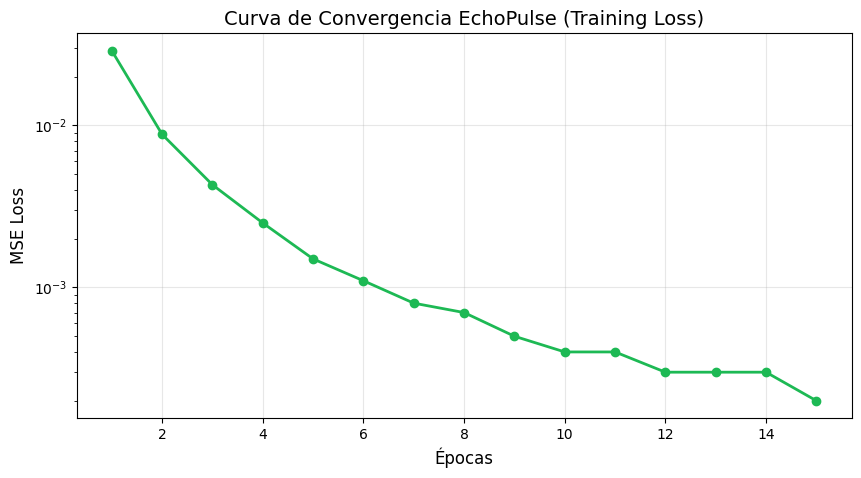

In [ ]:
import matplotlib.pyplot as plt

# Datos de  entrenamiento
epochs = list(range(1, 16))
loss_vals = [0.0289, 0.0088, 0.0043, 0.0025, 0.0015, 0.0011, 0.0008, 0.0007, 0.0005, 0.0004, 0.0004, 0.0003, 0.0003, 0.0003, 0.0002]

plt.figure(figsize=(10, 5))
plt.plot(epochs, loss_vals, marker='o', color='#1DB954', linestyle='-', linewidth=2)
plt.title('Curva de Convergencia EchoPulse (Training Loss)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.grid(True, alpha=0.3)
plt.yscale('log') # Escala logarítmica para ver mejor el detalle final
plt.show()